In [3]:
import dill

from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager, PassManager, StagedPassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, PadDynamicalDecoupling, ASAPScheduleAnalysis
from qiskit_ibm_runtime.fake_provider import FakeBrisbane 
from qiskit.providers.backend import BackendV2 as Backend
from qiskit_ibm_runtime.sampler import SamplerOptions, SamplerV2 as Sampler
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import XGate, YGate
from qiskit.quantum_info import hellinger_fidelity
import numpy as np
import pandas as pd 
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.circuit.equivalence_library import (SessionEquivalenceLibrary as sel,)
from qiskit.transpiler.passes import BasisTranslator
from qiskit_ibm_runtime import IBMBackend
from qiskit.visualization import timeline_drawer
from qiskit.transpiler import Target
from qiskit.circuit.library import efficient_su2

In [4]:
# 2. Save Function (Generic for any object)
def save_object(obj, filename):
    try:
        with open(filename, 'wb') as f:
            dill.dump(obj, f)
        print(f"Object saved to '{filename}'")
    except Exception as e:
        print(f"Error saving object: {e}")

# 3. Load Function
def load_object(filename):
    try:
        with open(filename, 'rb') as f:
            obj = dill.load(f)
        print(f"Object loaded from '{filename}'")
        return obj
    except Exception as e:
        print(f"Error loading object: {e}")

In [5]:
service = QiskitRuntimeService()

management.get:WARNING:2025-12-12 19:03:48,380: Loading default saved account


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from qiskit import transpile, QuantumCircuit
from qiskit.visualization import plot_gate_map


def get_backend_metrics(backend):
    """
    Extracts T1, T2, and Gate Errors (Coupling Quality) from the backend.
    """
    target = backend.target
    num_qubits = backend.num_qubits
    
    # 1. Extract T1 and T2 for every qubit
    t1_times    = []
    t2_times    = []
    DD_qubits   = {"good": [], "bad": [], "ugly": []}
    gate_errors = {'x':[], 'sx':[], 'measure':[], 'rz':[]}
    
    
    for i in range(num_qubits):

        ## Separate qubits accoriding to DD fitness
        try:
            # Get t1, t2 values (values are usually in seconds)
            props = backend.qubit_properties(i)
            t1_times.append(props.t1)
            t2_times.append(props.t2)

            ## Getting all the gate error each index of the list corresponds to qubit number
            for gate in list(gate_errors.keys()):
                gate_errors[gate].append(target[gate][(i,)].error)
            
            ## window of tolerance
            window = 0.5

            ## The Ugly
            if (2.0+window)*props.t1 < props.t2:
                DD_qubits['ugly'].append(i)

            ## The bad : Currently defining randomly but shall make better later...
            elif (2.0+window)*props.t1 >= props.t2 and (2.0-window)*props.t1 <= props.t2:
                DD_qubits['bad'].append(i)

            ## The Good
            else:
                DD_qubits['good'].append(i)

        except:
            t1_times.append(0)
            t2_times.append(0)

        
    gate_errors['cz'] = dict()
    # 2. Extract Coupling Error (Proxy for ZZ/Connection Quality)
    # We look for the 'ecr' or 'cx' gate error between coupled pairs
    coupling_map = target.build_coupling_map()
    
    
    # Find the dominant 2-qubit gate (usually 'ecr' or 'cz')
    two_q_gate = 'ecr' if 'ecr' in target.operation_names else 'cz'
    
    for edge in coupling_map:
        try:
            # Get error rate for the specific edge
            props = target[two_q_gate].get(edge)
            error = props.error if props else 1.0
            gate_errors['cz'][tuple(edge)] = error
        except:
            gate_errors['cz'][tuple(edge)] = 1.0

    return {
        "t1": np.array(t1_times),
        "t2": np.array(t2_times),
        "gate_errors": gate_errors,
        "coupling_map": coupling_map,
        "DD_qubits":DD_qubits
        }

# Initialize a backend (Replace this with your real service.backend("ibm_brisbane"))
fez = service.backend("ibm_fez")
metrics = get_backend_metrics(fez)

print(f"Extracted data for {torino.name}:")
print(f"Avg T1: {np.mean(metrics['t1'])*1e6:.2f} µs")
print(f"Avg T2: {np.mean(metrics['t2'])*1e6:.2f} µs")

# print(f"Avg Coupling Error: {np.mean(list(metrics['coupling_errors'].values())):.4f}")

Extracted data for ibm_fez:
Avg T1: 134.51 µs
Avg T2: 94.69 µs


In [14]:
def get_backend_map_with_circuit(backend_metrics, circuit, backend):
    ## Buliding colormap for qubits and connections
    qubit_color = []
    for i in range(len(backend_metrics['t1'])):
        if i in backend_metrics['DD_qubits']['ugly']:
            qubit_color.append("black")
        elif i in backend_metrics['DD_qubits']['bad']:
            qubit_color.append("orange") 
        else:
            qubit_color.append("grey") 
    line_color = []
    for e in backend_metrics["coupling_map"].get_edges():
        line_color.append("black") 
    
    ## Now for the circuit qubits
    circuit_qubits = circuit.layout.final_index_layout()

    for qubit in circuit_qubits:
        try:
            if qubit in backend_metrics['DD_qubits']['bad'] or qubit in backend_metrics['DD_qubits']['ugly']:
                qubit_color[qubit] = "#973018"
                
            else:
                qubit_color[qubit] = "#239A47"

        except IndexError:
            print("Your circuit contains qubits not on the backend. Recheck circuit.layout for more info")

        
        
    return plot_gate_map(backend, qubit_color=qubit_color, line_color=line_color, qubit_size=50, font_size=25, figsize=(14,14))

## Load Circuits

In [9]:
isa_ghz_dict = load_object("extensive_benchmarking_ghz_isa_circuits.dill")
isa_su2_dict = load_object("extensive_benchmarking_su2_isa_circuits.dill")

Object loaded from 'extensive_benchmarking_ghz_isa_circuits.dill'
Object loaded from 'extensive_benchmarking_su2_isa_circuits.dill'


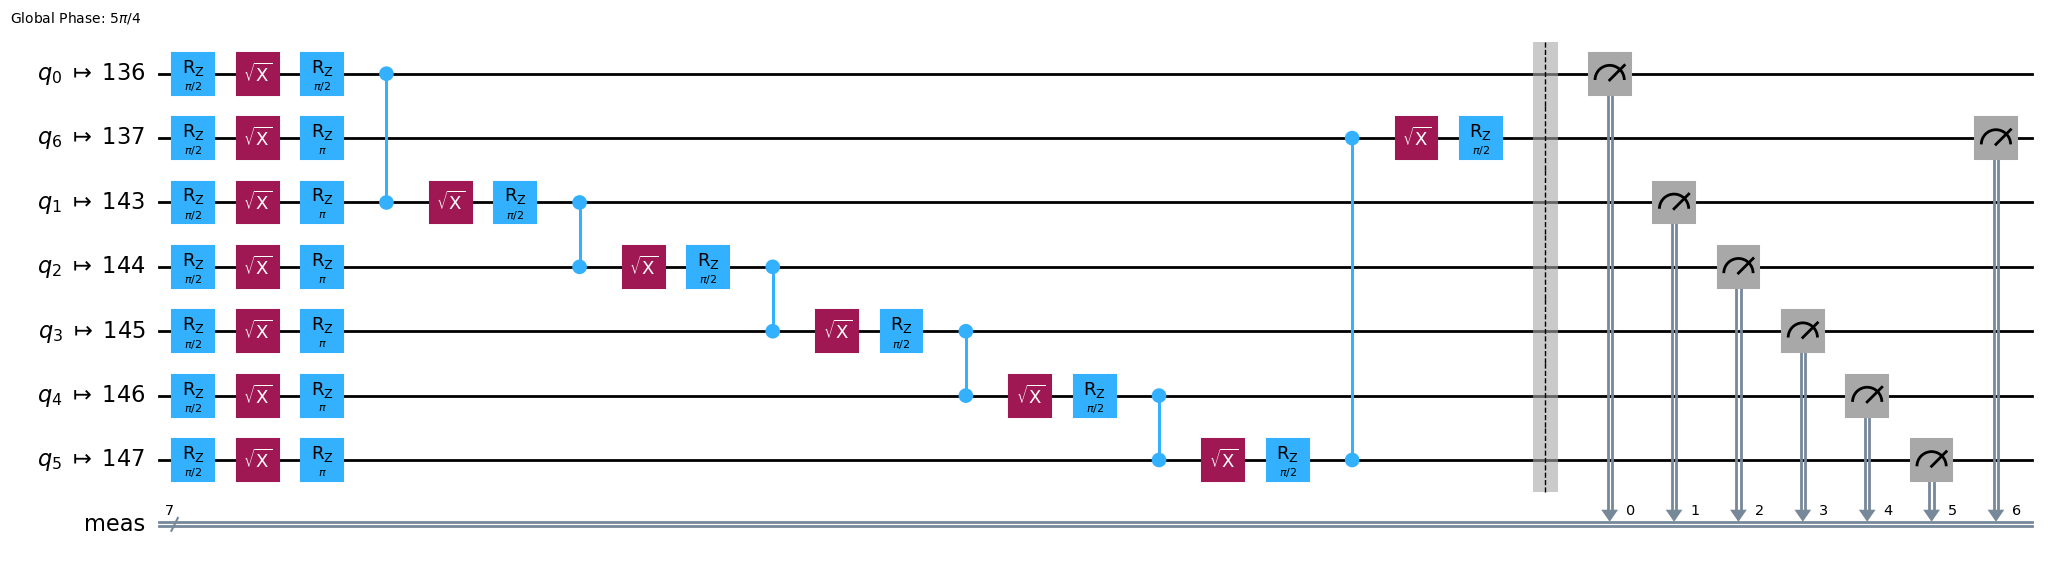

In [11]:
isa_ghz_dict[7][0].draw("mpl", idle_wires=False, fold=-1)

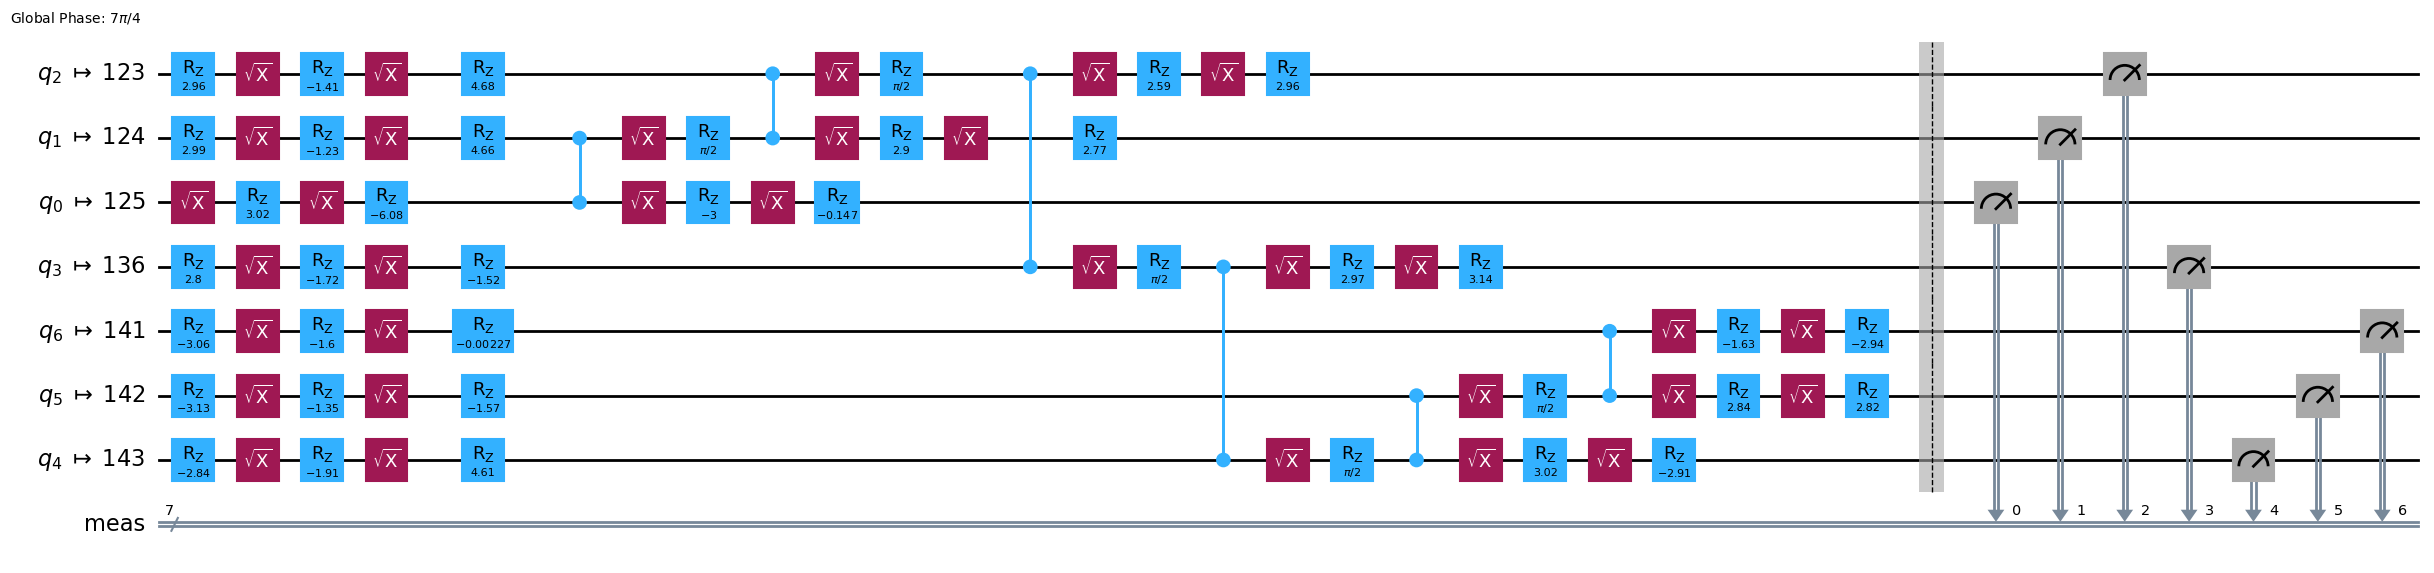

In [12]:
isa_su2_dict[7][0].draw("mpl", idle_wires=False, fold=-1)

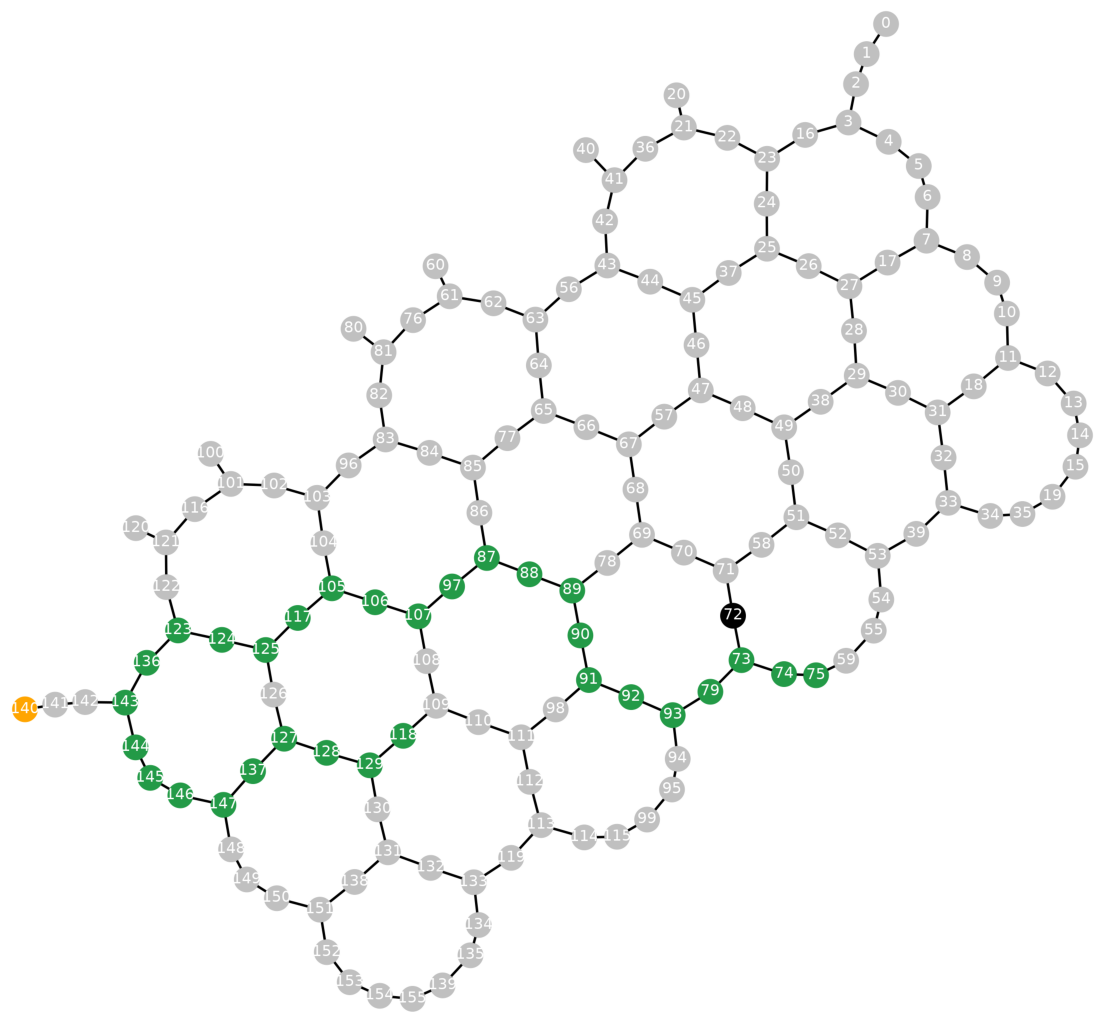

In [17]:

get_backend_map_with_circuit(metrics, isa_ghz_dict[30][0], fez)

# Analysing circuit times

In [26]:
import numpy as np

# Let's select one of the circuits to analyze
# We can pick any from isa_ghz_dict or isa_su2_dict
circuit = isa_ghz_dict[7][1]

print(f"Analyzing circuit: {circuit.name}")

# --- 1. Calculate idle time of each qubit ---

# Total duration of the scheduled circuit
if circuit.duration is None:
    raise ValueError("Circuit is not scheduled, cannot calculate idle time.")
    
total_duration = circuit.duration
duration_unit = circuit.unit

# The layout maps virtual qubits to physical qubits.
# We want to calculate idle time per physical qubit.


physical_q_indices = circuit.layout.final_index_layout() # This is a dict {virtual_qubit: physical_index}
qubit_busy_time = {p_idx: 0 for p_idx in physical_q_indices}

# Accumulate busy time for each physical qubit from all operations
for instruction in circuit.data:
    # instruction is a CircuitInst object (op, qubits, clbits)
    op_duration = instruction.operation.duration
    if op_duration is None:
        # Some operations might not have a duration if the circuit is not fully scheduled
        # or if they are ideal (like barriers, snapshots). We can skip them.
        continue
        
    # Get physical qubits this operation acts on
    for q in instruction.qubits:
        p_idx = physical_q_indices[q]
        qubit_busy_time[p_idx] += op_duration

# Calculate idle time for each qubit
qubit_idle_time = {}
for p_idx, busy_time in qubit_busy_time.items():
    idle_time = total_duration - busy_time
    qubit_idle_time[p_idx] = idle_time

print(f"\nCircuit duration: {total_duration} [{duration_unit}]")
print("\nQubit Idle Times (for physical qubits used by the circuit):")
for qubit_idx, idle_time in sorted(qubit_idle_time.items()):
    print(f"  Physical Qubit {qubit_idx}: {idle_time} [{duration_unit}]")

# --- 2. Calculate depth and two-qubit depth ---

# Overall circuit depth
depth = circuit.depth()

# Two-qubit gate depth
two_qubit_depth = circuit.depth(filter_function=lambda x: x.op.num_qubits == 2)

print("\nCircuit Depths:")
print(f"  Overall depth: {depth}")
print(f"  Two-qubit depth: {two_qubit_depth}")


Analyzing circuit: circuit-46


/tmp/ipykernel_5017/847848850.py:12: DeprecationWarning: The property ``qiskit.circuit.quantumcircuit.QuantumCircuit.duration`` is deprecated as of Qiskit 1.3.0. It will be removed in Qiskit 3.0.0.
  if circuit.duration is None:
/tmp/ipykernel_5017/847848850.py:15: DeprecationWarning: The property ``qiskit.circuit.quantumcircuit.QuantumCircuit.duration`` is deprecated as of Qiskit 1.3.0. It will be removed in Qiskit 3.0.0.
  total_duration = circuit.duration
/tmp/ipykernel_5017/847848850.py:16: DeprecationWarning: The property ``qiskit.circuit.quantumcircuit.QuantumCircuit.unit`` is deprecated as of Qiskit 1.3.0. It will be removed in Qiskit 3.0.0.
  duration_unit = circuit.unit


TypeError: list indices must be integers or slices, not qiskit.circuit.Qubit

In [39]:
type(isa_ghz_dict[7][1].data[0].qubits[0])

qiskit.circuit.Qubit

Qu

/tmp/ipykernel_18981/2404714799.py:4: DeprecationWarning: The class ``qiskit.circuit.library.quantum_volume.QuantumVolume`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.quantum_volume instead.
  qc = QuantumVolume(5, 2)


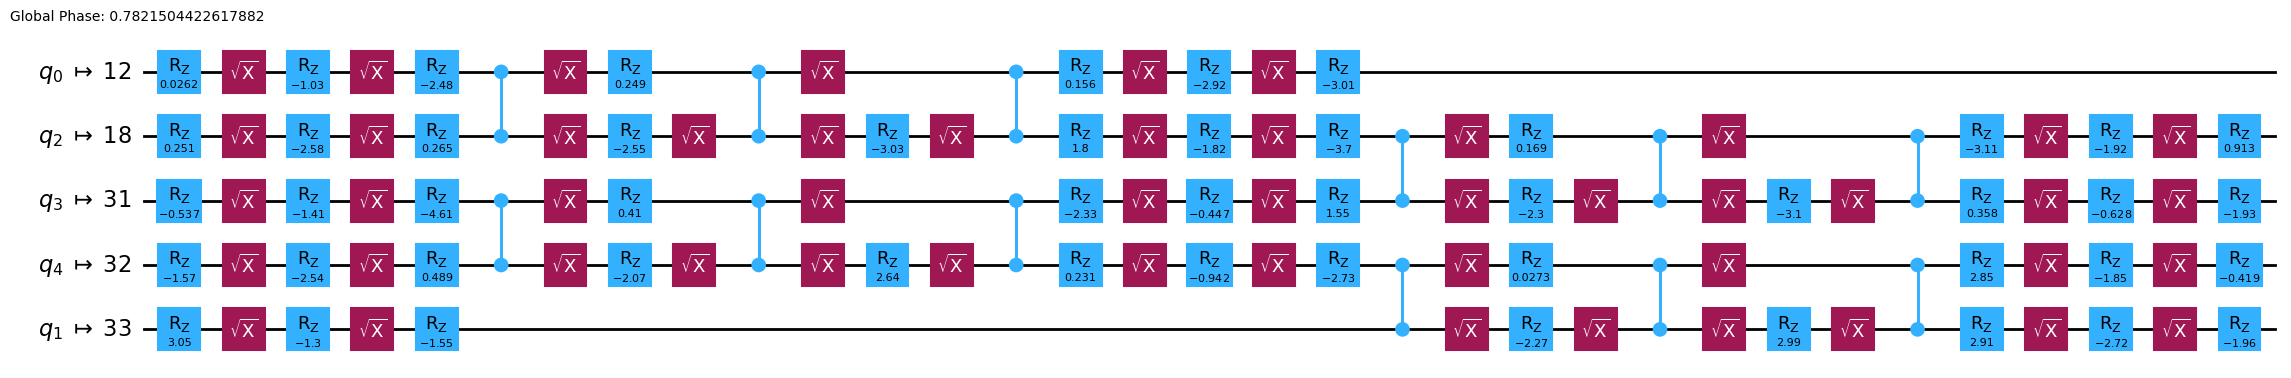

In [3]:
from qiskit.circuit.library import QuantumVolume

from qiskit.transpiler import generate_preset_pass_manager
qc = QuantumVolume(5, 2)

from qiskit_ibm_runtime.fake_provider import FakeTorino

backend = FakeTorino()
isa_qc = generate_preset_pass_manager(backend=backend, optimization_level=3).run(qc)

isa_qc.draw("mpl", idle_wires=False, fold=-1)


5 to 20 incerment 3
depth 2 

In [5]:
import dill

from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager, PassManager, StagedPassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, PadDynamicalDecoupling, ASAPScheduleAnalysis
from qiskit_ibm_runtime.fake_provider import FakeBrisbane 
from qiskit.providers.backend import BackendV2 as Backend
from qiskit_ibm_runtime.sampler import SamplerOptions, SamplerV2 as Sampler
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import XGate, YGate
from qiskit.quantum_info import hellinger_fidelity
import numpy as np
import pandas as pd 
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.circuit.equivalence_library import (SessionEquivalenceLibrary as sel,)
from qiskit.transpiler.passes import BasisTranslator
from qiskit_ibm_runtime import IBMBackend
from qiskit.visualization import timeline_drawer
from qiskit.transpiler import Target

In [ ]:

def prepare_ghz(n_qubits:int):
    ## Prepares standard ghz state with measurements on all qubits using measure_all() 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.measure_all()

    return circuit

def prepare_echo_ghz_with_xs(n_qubits:int):
    ## Prepares echo circuit with for ghz circuit. Xs at the end to make the expectation value 1. 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.barrier()

    circuit.compose(circuit.inverse(), inplace=True)

    circuit.barrier()

    circuit.x(range(n_qubits))

    circuit.measure_all()

    return circuit


class BenchmarkOptions:
    def __init__(
        self, 
        backend_name: str = "ibm_fez", 
        opt_level: int = 3, 
        do_dd: bool = False,
        scheduling_method: str | None = None, 
        dd_pulse: str | None = None
    ):
        # Allow any backend 
        try:
            self.backend = QiskitRuntimeService().backend(backend_name)
        except Exception as e:
            print(f"Warning: Could not connect to backend '{backend_name}'. {e}")
            self.backend = None

        self.opt_level = opt_level
        self.do_dd = do_dd
        self.dd_pulse = dd_pulse
        self.scheduling_method = scheduling_method
        self.basis_gates = list(self.backend.target.operation_names)

        ## Default pulse sequence is xx
        if self.do_dd and self.dd_pulse is None:
            self.dd_pulse = 'xx'

        


def pm_for_backend(bknd, opt_level:int, seed:int, scheduling_method:str = "none", target:Target | None = None):
    ## Returns a normal (no dd) PassManager from generate_preset_pass_manager for given opt_level and backend(bknd) al
    
    if target is None:
        target = bknd.target
        
    ## for no scheduling case
    if scheduling_method == 'none':
        pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed)
    
    ## for "alap" and "asap" cases
    else:
        pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed, scheduling_method=scheduling_method, target=target)
    
    return pm


def make_passmanager(benchmark_options:BenchmarkOptions):
    
    backend = benchmark_options.backend if benchmark_options.backend else QiskitRuntimeService().backend("ibm_fez")
    opt_level = benchmark_options.opt_level if benchmark_options.opt_level else 3
    scheduling_method = benchmark_options.scheduling_method if benchmark_options.scheduling_method else 'none'

    print(f"Transpilation options:\nbackend:{backend}\noptlevel:{opt_level}\nscheduling:{scheduling_method}\ndo_dd:{benchmark_options.do_dd}\ndd_pulse:{benchmark_options.dd_pulse}")

    ## Fix seed for reprodicubility
    pm_seed = 42069

    ## Include DD
    if benchmark_options.do_dd:
        return prepare_dd_pm(benchmark_options=benchmark_options)

    ## Defaults to no dd PM with opt_level = 3 and given scheduling_method
    else:
        return pm_for_backend(bknd=backend, opt_level=opt_level, seed=pm_seed, scheduling_method=scheduling_method)




def naked_sampler(mode, shots=4096):
    ## Sampler with no error mitigation or supression for any mode (job, batch). ALL OPTIONS ARE DISABLED. 
    options = SamplerOptions(default_shots=shots, dynamical_decoupling={"enable": False}, twirling={"enable_gates": False, "enable_measure": False})
    sampler = Sampler(mode=mode, options=options)
    return sampler

def execute_on_hardware(bknd, sampler_pub):
    ## Batch mode execution of quantum circuits on hardware
    with Batch(backend=bknd) as batch:
        sampler = naked_sampler(mode=batch, shots=4096)
        # summary = summarize_backend(bknd)
        job = sampler.run(sampler_pub)
        id = job.job_id()
        print(id)
    return id


def get_result_from_id(service, id):
    # Get Result object from service using id

    job = service.job(id)
    result = job.result()

    return result
    

def prepare_dd_pm(benchmark_options:BenchmarkOptions):
    ## Returns a PassManager for DD with customizable DD sequence and scheduelling method. 

    # Default Sequence
    sequenece = [XGate(), XGate()]

    target = benchmark_options.backend.target

    seq = benchmark_options.dd_pulse

    if seq.lower() == "xpxm":
        sequenece = [XGate(), XGate().inverse()]

    if seq.lower() == 'xy':
        from qiskit.transpiler import InstructionProperties

        sequenece = [XGate(), YGate(), XGate(), YGate()]

        y_gate_properties = {}

        for qubit in range(target.num_qubits):
            y_gate_properties.update(
                {
                    (qubit,): InstructionProperties(
                        duration=target["x"][(qubit,)].duration,
                        error=target["x"][(qubit,)].error,
                    )
                }
            )
        
        target.add_instruction(YGate(), y_gate_properties)

    


    ## Prepare a preset passmanager for backend optimization_level=3 and target (target is modified if seq = 'xy)
    pm = pm_for_backend(bknd=benchmark_options.backend, opt_level=3, seed=42069, target=target)

    try:
            
        if benchmark_options.scheduling_method:    
                if benchmark_options.scheduling_method == 'asap':
                    pm.scheduling.append(ASAPScheduleAnalysis(target=target))

                    pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))
                
                elif benchmark_options.scheduling_method == 'alap':
                    pm.scheduling.append(ALAPScheduleAnalysis(target=target))
                    pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))

    except:
        print(f"Error in sequence({seq}) or scheduling method({benchmark_options.scheduling_method})")

    return pm




def mega_transpiler(circuit:QuantumCircuit, dd_pm:StagedPassManager, benchmark_options:BenchmarkOptions) -> QuantumCircuit:
    
    isa_dd_circuit = dd_pm.run(circuit)
    
    ## Final Translation to convert Y gates into basis equivalent gates
    if benchmark_options.do_dd is True:
        if benchmark_options.dd_pulse.lower() == 'xy':
            from qiskit.circuit.equivalence_library import (SessionEquivalenceLibrary as sel,)
            from qiskit.transpiler.passes import BasisTranslator
            

            basis_gates = benchmark_options.basis_gates
            

            return BasisTranslator(sel, basis_gates)(isa_dd_circuit)
        else:
            return isa_dd_circuit

    ## Normal case for xx dd and xpxm dd
    else:
        return isa_dd_circuit
    



def get_fidelity_for_circuit(ideal, simulated, dd_counts_list):

    ## Returns List[List] of hellinger fidelity results. Outer list is of length 2 and contains
    # 0 :- List of len 3 with hellinger fidelity compared to ideal counts. [hellinger_simulated, hellinger_no_dd, hellinger_dd]
    # 1 :- List of len 2 with hellinger fidelity compared to simulated counts. [hellinger_no_dd, hellinger_dd]

    # Calculating hellinger fidelity compared to ideal counts

    hellinger_results = []

    for target_result in [simulated] + dd_counts_list:

        hellinger_results.append(hellinger_fidelity(ideal, target_result))

    # Calculate hellinger fidelity compared to simulated counts

    alt_hellinger_results = []

    for target_result in dd_counts_list:
        alt_hellinger_results.append(hellinger_fidelity(simulated, target_result))



    return [hellinger_results, alt_hellinger_results]



